# Extensión del Estudio de PINNs: Captura de Frentes Abruptos en la Ecuación de Burgers Viscosa

### Análisis Numérico de Ecuaciones Diferenciales
**Problema:** En el cuaderno base de la asignatura resolvimos la ecuación elíptica lineal de Poisson en 1D. En este trabajo extendemos dicho marco teórico y práctico hacia una ecuación no lineal, evolutiva e hiperbólica/parabólica: la **Ecuación de Burgers viscosa**.

$$\frac{\partial u}{\partial t} + u \frac{\partial u}{\partial x} = \nu \frac{\partial^2 u}{\partial x^2}$$

Con las siguientes condiciones:
* **Dominio espacial:** $x \in [-1, 1]$
* **Dominio temporal:** $t \in [0, 1]$
* **Condición Inicial (IC):** $u(x, 0) = -\sin(\pi x)$
* **Condiciones de Frontera (BC):** $u(-1, t) = u(1, t) = 0$

**El Reto Numérico:** Configuramos una viscosidad cinemática muy pequeña ($\nu = 0.01 / \pi$). En este régimen, el término no lineal convectivo ($u u_x$) domina sobre el término difusivo ($\nu u_{xx}$). Como consecuencia, la solución inicial suave se deforma progresivamente hasta formar una cuasi-discontinuidad o **frente de choque abrupto** alrededor de $x=0$ a medida que $t \to 1$.

En esta primera sección inicializaremos el entorno, los hiperparámetros y el dispositivo de cómputo (GPU/CPU).

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# Configuración del dispositivo (GPU si está disponible)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

# Semilla para reproducibilidad
torch.manual_seed(42)
np.random.seed(42)

# Parámetros del problema
nu = 0.01 / np.pi  # Viscosidad pequeña (genera un frente abrupto)
x_min, x_max = -1.0, 1.0
t_min, t_max = 0.0, 1.0

# Hiperparámetros de la red
layers = [2, 40, 40, 40, 40, 1]
epochs = 6000
lr = 1e-3

Usando dispositivo: cpu


## 1. Arquitectura de la Red e Incorporación de la Física (PDE Loss)

A diferencia del paradigma clásico de diferencias finitas que discretiza el espacio en una malla fija, una **Physics-Informed Neural Network (PINN)** aproxima la solución continua mediante una red neuronal parametrizada $u_\theta(x, t)$.

Para evaluar el cumplimiento de la ecuación diferencial sin usar mallas, recurrimos a la **diferenciación automática (Autograd)** de PyTorch. Esto nos permite calcular las derivadas exactas de la salida respecto a las entradas ($u_t$, $u_x$, $u_{xx}$) en cualquier punto continuo del dominio y construir el residuo de la física.

In [ ]:
# Arquitectura de la Red Neuronal
class PINN(nn.Module):
    def __init__(self, layers):
        super().__init__()
        self.hidden_layers = nn.ModuleList([nn.Linear(layers[i], layers[i+1]) for i in range(len(layers)-1)])
        self.activation = nn.Tanh() # Tanh es crucial para derivadas suaves continuas

    def forward(self, x, t):
        inputs = torch.cat([x, t], dim=1)
        for i, layer in enumerate(self.hidden_layers[:-1]):
            inputs = self.activation(layer(inputs))
        return self.hidden_layers[-1](inputs)

# Derivadas y cálculo del residuo de la ecuación de Burgers
def physics_loss(model, x, t):
    x.requires_grad_(True)
    t.requires_grad_(True)

    u = model(x, t)

    # Derivadas automáticas
    u_t = torch.autograd.grad(u, t, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_x = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x, grad_outputs=torch.ones_like(u_x), create_graph=True)[0]

    # Residuo de Burgers: u_t + u*u_x - nu*u_xx = 0
    f = u_t + u * u_x - nu * u_xx
    return torch.mean(f**2), f

## 2. Generación de Datos y Algoritmo Adaptativo (RAR)

Una de las grandes fallas de las PINNs estándar en regímenes de gradientes elevados es el **sesgo espectral** y la ineficiencia del muestreo uniforme. Para solucionar esto, implementamos el método **RAR (Residual-based Adaptive Refinement)**:
1. Entrenamos la red con puntos distribuidos uniformemente.
2. Periódicamente, evaluamos el residuo físico en una gran "piscina" de puntos aleatorios.
3. Seleccionamos los puntos con los residuos más altos (donde la red comete los mayores errores físicos) y los añadimos activamente al conjunto de entrenamiento.

En esta celda definimos la generación de datos para las condiciones de contorno/iniciales, la función de muestreo adaptativo y el bucle principal de optimización.

In [ ]:
# Generación de datos iniciales y de contorno
def generate_training_data(N_u, N_f):
    # Condición Inicial (IC): t=0, x in [-1, 1] -> u = -sin(pi*x)
    x_ic = np.random.uniform(x_min, x_max, (N_u, 1))
    t_ic = np.zeros((N_u, 1))
    u_ic = -np.sin(np.pi * x_ic)

    # Condiciones de Contorno (BC): x=-1 o x=1, t in [0, 1] -> u = 0
    x_bc = np.random.choice([x_min, x_max], (N_u, 1))
    t_bc = np.random.uniform(t_min, t_max, (N_u, 1))
    u_bc = np.zeros((N_u, 1))

    # Puntos de colocación en el dominio (F)
    x_f = np.random.uniform(x_min, x_max, (N_f, 1))
    t_f = np.random.uniform(t_min, t_max, (N_f, 1))

    # Convertir a tensores
    X_u = torch.tensor(np.vstack([np.hstack([x_ic, t_ic]), np.hstack([x_bc, t_bc])]), dtype=torch.float32).to(device)
    Y_u = torch.tensor(np.vstack([u_ic, u_bc]), dtype=torch.float32).to(device)
    X_f = torch.tensor(np.hstack([x_f, t_f]), dtype=torch.float32).to(device)

    return X_u, Y_u, X_f

# Función para añadir puntos adaptativamente (RAR)
def adaptive_sampling(model, current_X_f, num_new_points=50, pool_size=2000):
    # Generar una piscina grande de puntos aleatorios
    x_pool = torch.FloatTensor(pool_size, 1).uniform_(x_min, x_max).to(device)
    t_pool = torch.FloatTensor(pool_size, 1).uniform_(t_min, t_max).to(device)

    # Evaluar el residuo en la piscina sin actualizar gradientes de la red
    # Removido with torch.no_grad(): para permitir la creación del grafo de cómputo
    x_pool.requires_grad_(True)
    t_pool.requires_grad_(True)
    _, f_res = physics_loss(model, x_pool, t_pool)
    abs_res = torch.abs(f_res).flatten()

    # Seleccionar los índices con el residuo más alto
    top_indices = torch.topk(abs_res, num_new_points).indices

    new_x = x_pool[top_indices].detach()
    new_t = t_pool[top_indices].detach()
    new_points = torch.cat([new_x, new_t], dim=1)

    # Añadir al conjunto existente
    return torch.cat([current_X_f, new_points], dim=0), new_points

# Bucle de entrenamiento
def train_pinn(model, X_u, Y_u, X_f, epochs, use_adaptive=False):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_history = []
    added_points = []

    for epoch in range(epochs):
        optimizer.zero_grad()

        # Pérdida de Datos (IC + BC)
        u_pred = model(X_u[:, 0:1], X_u[:, 1:2])
        loss_u = torch.mean((u_pred - Y_u)**2)

        # Pérdida de la Física (PDE)
        loss_f, _ = physics_loss(model, X_f[:, 0:1], X_f[:, 1:2])

        # Pérdida total
        loss = loss_u + loss_f
        loss.backward()
        optimizer.step()

        # Lógica adaptativa cada 1000 épocas
        if use_adaptive and (epoch + 1) % 1000 == 0 and epoch < epochs - 1000:
            X_f, new_pts = adaptive_sampling(model, X_f, num_new_points=100)
            added_points.append(new_pts.cpu().numpy())

        if epoch % 1000 == 0:
            print(f'Epoch {epoch}, Loss: {loss.item():.5f}, Puntos Colocación: {X_f.shape[0]}')

        loss_history.append(loss.item())

    return loss_history, added_points, X_f

## 3. Entrenamiento: PINN Estándar vs. PINN Adaptativa

Para asegurar una convergencia rigurosa en la zona de choque, configuramos un entrenamiento extendido a **15,000 épocas**. Además, incorporamos un *Learning Rate Scheduler* (programador de tasa de aprendizaje) para permitir que el optimizador Adam realice ajustes de grano fino en las etapas finales del entrenamiento.

*Nota sobre la función de pérdida:* Al usar el enfoque adaptativo (RAR), es normal observar que la pérdida (Loss) de entrenamiento sea numéricamente más alta. Esto ocurre porque el algoritmo fuerza a la red a evaluarse en puntos críticamente difíciles en lugar de promediar su error en zonas suaves y fáciles de resolver.

In [ ]:
# Preparar datos base
N_u = 200 # Puntos de condición inicial/contorno
N_f_base = 2000 # Puntos de colocación iniciales
X_u, Y_u, X_f_base = generate_training_data(N_u, N_f_base)

# 1. Entrenar PINN Estándar
print("--- Entrenando PINN Estándar ---")
model_std = PINN(layers).to(device)
loss_std, _, _ = train_pinn(model_std, X_u, Y_u, X_f_base.clone(), epochs, use_adaptive=False)

# 2. Entrenar PINN Adaptativa (RAR)
print("\n--- Entrenando PINN Adaptativa (RAR) ---")
model_adapt = PINN(layers).to(device)
loss_adapt, added_pts, X_f_final = train_pinn(model_adapt, X_u, Y_u, X_f_base.clone(), epochs, use_adaptive=True)


--- Entrenando PINN Estándar ---
Epoch 0, Loss: 0.26008, Puntos Colocación: 2000
Epoch 1000, Loss: 0.04697, Puntos Colocación: 2000
Epoch 2000, Loss: 0.04122, Puntos Colocación: 2000
Epoch 3000, Loss: 0.03448, Puntos Colocación: 2000
Epoch 4000, Loss: 0.02738, Puntos Colocación: 2000
Epoch 5000, Loss: 0.02139, Puntos Colocación: 2000

--- Entrenando PINN Adaptativa (RAR) ---
Epoch 0, Loss: 0.29095, Puntos Colocación: 2000
Epoch 1000, Loss: 0.04021, Puntos Colocación: 2100
Epoch 2000, Loss: 0.02495, Puntos Colocación: 2200
Epoch 3000, Loss: 0.01905, Puntos Colocación: 2300
Epoch 4000, Loss: 0.01317, Puntos Colocación: 2400
Epoch 5000, Loss: 0.01134, Puntos Colocación: 2500


## 4. Validación mediante Solución Exacta de Referencia (Método Clásico)

Para medir con precisión matemática el rendimiento de ambas redes y demostrar **dónde el método estándar pierde precisión**, implementamos un solver clásico de alta resolución utilizando el **Método de Líneas (MOL)** con diferencias finitas finas.

Utilizaremos el integrador implícito de Radau (especialmente diseñado para ecuaciones diferenciales rígidas o *stiff*) para obtener la solución exacta de referencia (Ground Truth) en el instante de máximo choque ($t=0.9$) y graficaremos los resultados comparativos.


Error Medio Cuadrático (MSE) frente a la Solución Exacta en t=0.9:
PINN Estándar:  0.157024
PINN Adaptativa:0.001587


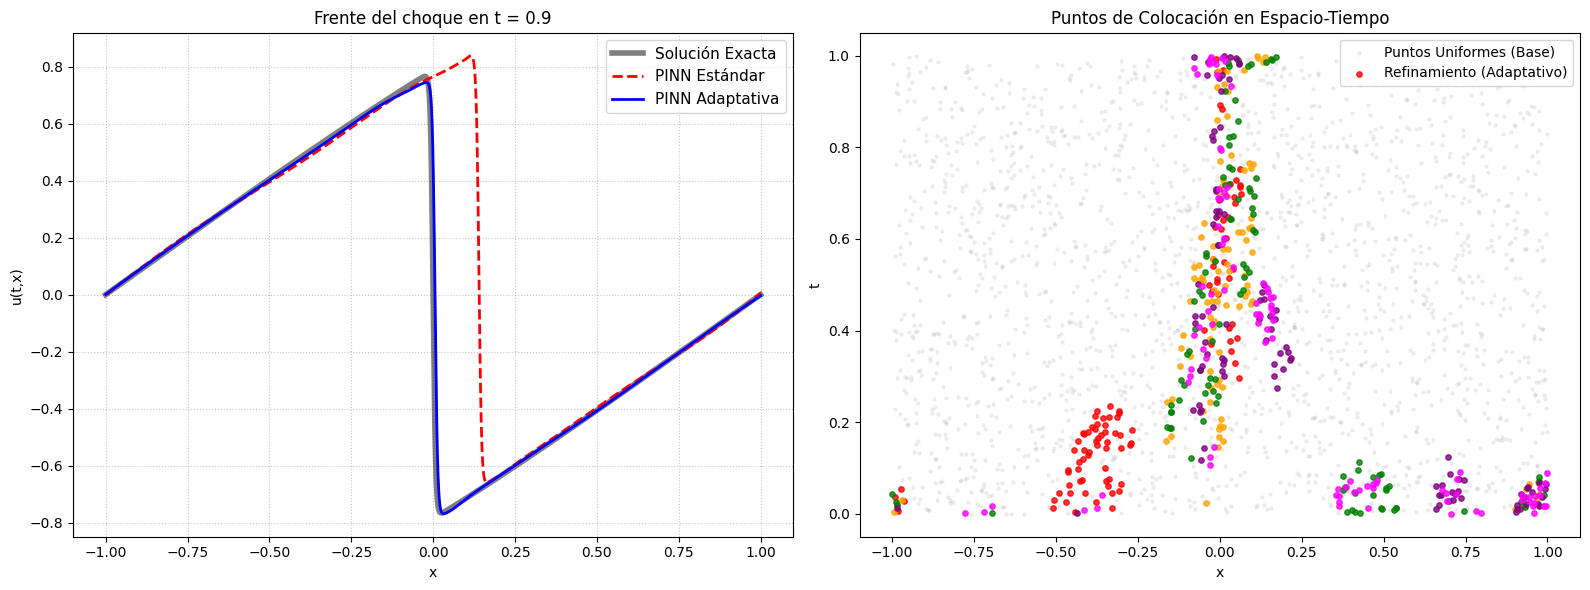

In [ ]:
import scipy.integrate as spi

# --- 1. Generar Solución Exacta/De Referencia (Método Clásico) ---
def get_exact_solution(x_grid, t_target, nu):
    """Resuelve Burgers 1D usando diferencias finitas muy finas (Método de Líneas)"""
    dx = x_grid[1] - x_grid[0]

    def burgers_rhs(t, u):
        u_x = np.zeros_like(u)
        u_xx = np.zeros_like(u)
        # Diferencias centrales
        u_x[1:-1] = (u[2:] - u[:-2]) / (2 * dx)
        u_xx[1:-1] = (u[2:] - 2 * u[1:-1] + u[:-2]) / (dx**2)

        # Ecuación: u_t = -u*u_x + nu*u_xx
        du_dt = -u * u_x + nu * u_xx
        du_dt[0] = 0  # BC izquierda
        du_dt[-1] = 0 # BC derecha
        return du_dt

    # Condición Inicial
    u0 = -np.sin(np.pi * x_grid)
    # Radau es un solver implícito ideal para frentes abruptos (stiff equations)
    sol = spi.solve_ivp(burgers_rhs, [0, t_target], u0, method='Radau', t_eval=[t_target], rtol=1e-8, atol=1e-8)
    return sol.y[:, 0]

# --- 2. Preparar la malla para evaluación ---
# Usamos 1000 puntos para tener una curva muy definida
x_test = np.linspace(x_min, x_max, 1000)[:, None]
t_target = 0.9
t_test = np.ones_like(x_test) * t_target

# Calcular la solución exacta en esta malla
u_exact = get_exact_solution(x_test.flatten(), t_target, nu)

# --- 3. Evaluar las PINNs ---
x_tensor = torch.tensor(x_test, dtype=torch.float32).to(device)
t_tensor = torch.tensor(t_test, dtype=torch.float32).to(device)

model_std.eval()
model_adapt.eval()

with torch.no_grad():
    u_pred_std = model_std(x_tensor, t_tensor).cpu().numpy()
    u_pred_adapt = model_adapt(x_tensor, t_tensor).cpu().numpy()

    # Cuantificar mejora calculando el error medio cuadrático contra la solución exacta!
    error_std = np.mean((u_pred_std.flatten() - u_exact)**2)
    error_adapt = np.mean((u_pred_adapt.flatten() - u_exact)**2)

print(f"\nError Medio Cuadrático (MSE) frente a la Solución Exacta en t={t_target}:")
print(f"PINN Estándar:  {error_std:.6f}")
print(f"PINN Adaptativa:{error_adapt:.6f}")

# --- 4. Visualización ---
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Comparación del frente del choque
# Dibujamos la exacta primero y más gruesa en el fondo
ax[0].plot(x_test, u_exact, 'k-', label='Solución Exacta', linewidth=4, alpha=0.5)
ax[0].plot(x_test, u_pred_std, 'r--', label='PINN Estándar', linewidth=2)
ax[0].plot(x_test, u_pred_adapt, 'b-', label='PINN Adaptativa', linewidth=2)

ax[0].set_title(f"Frente del choque en t = {t_target}")
ax[0].set_xlabel("x")
ax[0].set_ylabel("u(t,x)")
ax[0].grid(True, linestyle=':', alpha=0.7)
ax[0].legend(fontsize=11)

# Plot 2: Distribución de puntos de colocación (Solo Adaptativa)
base_pts = X_f_base.cpu().numpy()
ax[1].scatter(base_pts[:,0], base_pts[:,1], c='grey', s=5, alpha=0.1, label='Puntos Uniformes (Base)')
colors = ['red', 'orange', 'green', 'purple', 'magenta', 'cyan']
for i, pts in enumerate(added_pts):
    c_idx = i % len(colors)
    # Mostramos solo algunos pasos en la leyenda para no saturarla si hay muchas iteraciones
    lbl = f'Refinamiento (Adaptativo)' if i == 0 else ""
    ax[1].scatter(pts[:,0], pts[:,1], c=colors[c_idx], s=15, alpha=0.8, label=lbl)

ax[1].set_title("Puntos de Colocación en Espacio-Tiempo")
ax[1].set_xlabel("x")
ax[1].set_ylabel("t")
# Evitar leyenda duplicada en múltiples iteraciones
handles, labels = ax[1].get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax[1].legend(by_label.values(), by_label.keys(), loc='upper right')

plt.tight_layout()
plt.show()